# 05 — Product-Market Segmentation (Clustering)

Goal: discover natural groups of `Product Family x Segment x Geography` combinations, rather
than relying only on the company's predefined categories. We build a feature set per combination
(economic value, deal economics, growth, upsell mix, volatility), then compare K-Means, Gaussian
Mixture Models, and hierarchical clustering, validating with silhouette score.

Grain: `Product Family x Segment x Geography` combination (from the line-item table), not
individual opportunities -- clustering at the opportunity level would mostly just re-discover
segment/geography, which we already know; clustering the *combinations* is what can reveal
archetypes like "high-value mature markets" vs "emerging high-growth combinations".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

pd.options.display.float_format = "{:,.2f}".format
sns.set_style("whitegrid")
RANDOM_STATE = 42

## Load data

In [2]:
import os

PROCESSED_PATH = "../data/processed/opportunities.parquet"
STG_PATH = "../data/processed/stg_sales_clean.parquet"
RAW_PATH = "../data/raw/company_sales.xlsx"

if os.path.exists(PROCESSED_PATH) and os.path.exists(STG_PATH):
    opportunities = pd.read_parquet(PROCESSED_PATH)
    opportunities["close_date"] = pd.to_datetime(opportunities["close_date"])
    sales_line_items = pd.read_parquet(STG_PATH)
else:
    sales_raw = pd.read_excel(RAW_PATH, sheet_name="Sales Data")
    sales_raw["Close Date"] = pd.to_datetime(sales_raw["Close Date"])
    sales = sales_raw.drop_duplicates().copy()
    sales_line_items = sales.rename(columns={
        "Opportunity ID": "opportunity_id", "Opp Owner Geo": "opp_owner_geo", "Segment": "segment",
        "Opportunity Type": "opportunity_type", "Product Line": "product_line",
        "Product Family": "product_family", "Total Price": "total_price", "Close Date": "close_date",
    })
    opportunity_value = sales.groupby("Opportunity ID")["Total Price"].sum().reset_index(name="opportunity_value")
    opportunity_attributes = (
        sales.groupby("Opportunity ID")
        .agg({"Opp Owner Geo": "first", "Segment": "first", "Opportunity Type": "first", "Close Date": "first"})
        .reset_index().rename(columns={"Opportunity ID": "opportunity_id", "Opp Owner Geo": "opp_owner_geo",
                                        "Segment": "segment", "Opportunity Type": "opportunity_type", "Close Date": "close_date"})
    )
    opportunities = opportunity_attributes.merge(
        opportunity_value.rename(columns={"Opportunity ID": "opportunity_id"}), on="opportunity_id", how="left"
    )
    opportunities["year"] = opportunities["close_date"].dt.year

sales_line_items["close_date"] = pd.to_datetime(sales_line_items["close_date"])
sales_line_items["year"] = sales_line_items["close_date"].dt.year

print("Line items:", sales_line_items.shape)
sales_line_items.head()

Line items: (383, 11)


,opportunity_id,Opp Owner User ID,opp_owner_geo,segment,opportunity_type,close_date,product_line,product_family,total_price,Rep Name,year
0,0061Y00000QA0nIxRU,0054z00000AAVA1E0V,AMER,Enterprise,New Business,2019-09-06,Workforce,Workforce - C,"48,989.32",Alice Chen,2019
1,0061Y00000QA0nIxRU,0054z00000AAVA1E0V,AMER,Enterprise,New Business,2019-09-06,Workforce,Workforce - B,"36,741.99",Alice Chen,2019
2,0061Y00000QA0nIxRU,0054z00000AAVA1E0V,AMER,Enterprise,New Business,2019-09-06,Workforce,Workforce - A,"24,494.66",Alice Chen,2019
4,0061Y00000QA0nIxXH,0054z00000AAFA1E0p,AMER,Enterprise,Upsell,2019-04-12,Workforce,Workforce - B,"8,461.79",Bob Smith,2019
5,0061Y00000QA0nIxXH,0054z00000AAFA1E0p,AMER,Enterprise,Upsell,2019-04-12,Workforce,Workforce - A,"5,641.19",Bob Smith,2019


## Build the combination-level feature table

Grain: one row per `Product Family x Segment x Geography` combination that has at least a
minimal amount of activity. Features:

- **Total value** (economic value)
- **Opportunity volume** (distinct opportunities touching this combination)
- **Average / median deal size** (deal economics)
- **Growth**: value in the most recent full year vs the prior full year
- **Upsell proportion**: share of this combination's value that comes from Upsell opportunities
- **Value volatility**: coefficient of variation of line-item values within the combination

We require a minimum number of line items per combination so we're not clustering on
statistically meaningless single-deal "combinations".

In [3]:
MIN_LINE_ITEMS = 2

combo_base = (
    sales_line_items
    .groupby(["product_family", "segment", "opp_owner_geo"])
    .agg(
        total_value=("total_price", "sum"),
        n_line_items=("total_price", "count"),
        n_opportunities=("opportunity_id", "nunique"),
        avg_deal=("total_price", "mean"),
        median_deal=("total_price", "median"),
        std_deal=("total_price", "std"),
    )
    .reset_index()
)
combo_base = combo_base[combo_base["n_line_items"] >= MIN_LINE_ITEMS].copy()
combo_base["value_volatility"] = (combo_base["std_deal"] / combo_base["avg_deal"]).fillna(0)

print(f"Combinations with >= {MIN_LINE_ITEMS} line items: {len(combo_base)}")
combo_base.head()

Combinations with >= 2 line items: 24


,product_family,segment,opp_owner_geo,total_value,n_line_items,n_opportunities,avg_deal,median_deal,std_deal,value_volatility
0,CIAM - A,Corporate,APAC,"33,228.00",3,1,"11,076.00","11,928.00","3,904.35",0.35
1,CIAM - A,Corporate,EMEA,"221,099.68",10,5,"22,109.97","13,470.12","29,818.81",1.35
2,CIAM - A,Enterprise,AMER,"467,453.50",9,4,"51,939.28","37,154.36","39,378.95",0.76
3,CIAM - A,Enterprise,APAC,"138,744.65",2,1,"69,372.32","69,372.32","66,712.96",0.96
4,CIAM - A,Enterprise,EMEA,"907,271.46",13,3,"69,790.11","64,564.46","53,445.02",0.77


In [4]:
# Upsell proportion per combination
upsell_share = (
    sales_line_items
    .groupby(["product_family", "segment", "opp_owner_geo", "opportunity_type"])["total_price"]
    .sum()
    .unstack(fill_value=0)
)
upsell_share["upsell_proportion"] = upsell_share.get("Upsell", 0) / upsell_share.sum(axis=1)
upsell_share = upsell_share[["upsell_proportion"]].reset_index()

combo_base = combo_base.merge(upsell_share, on=["product_family", "segment", "opp_owner_geo"], how="left")
combo_base["upsell_proportion"] = combo_base["upsell_proportion"].fillna(0)
combo_base.head()

,product_family,segment,opp_owner_geo,total_value,n_line_items,n_opportunities,avg_deal,median_deal,std_deal,value_volatility,upsell_proportion
0,CIAM - A,Corporate,APAC,"33,228.00",3,1,"11,076.00","11,928.00","3,904.35",0.35,1.00
1,CIAM - A,Corporate,EMEA,"221,099.68",10,5,"22,109.97","13,470.12","29,818.81",1.35,0.32
2,CIAM - A,Enterprise,AMER,"467,453.50",9,4,"51,939.28","37,154.36","39,378.95",0.76,0.50
3,CIAM - A,Enterprise,APAC,"138,744.65",2,1,"69,372.32","69,372.32","66,712.96",0.96,0.00
4,CIAM - A,Enterprise,EMEA,"907,271.46",13,3,"69,790.11","64,564.46","53,445.02",0.77,1.00


In [5]:
# Growth: most recent full year vs prior full year, per combination.
# 2022 has only 1 opportunity company-wide, so we treat 2019 and 2020 as the two comparable full years.
yearly_value = (
    sales_line_items[sales_line_items["year"].isin([2019, 2020])]
    .groupby(["product_family", "segment", "opp_owner_geo", "year"])["total_price"]
    .sum()
    .unstack(fill_value=0)
)
for yr in [2019, 2020]:
    if yr not in yearly_value.columns:
        yearly_value[yr] = 0

yearly_value["growth_2019_2020"] = np.where(
    yearly_value[2019] > 0,
    (yearly_value[2020] - yearly_value[2019]) / yearly_value[2019],
    np.where(yearly_value[2020] > 0, 1.0, 0.0)  # combination appeared new in 2020 -> treat as +100% growth
)
yearly_value = yearly_value[["growth_2019_2020"]].reset_index()

combo_base = combo_base.merge(yearly_value, on=["product_family", "segment", "opp_owner_geo"], how="left")
combo_base["growth_2019_2020"] = combo_base["growth_2019_2020"].fillna(0)

combo_base["combo_label"] = (
    combo_base["product_family"] + " | " + combo_base["segment"] + " | " + combo_base["opp_owner_geo"]
)

combo_base.head(10)

,product_family,segment,opp_owner_geo,total_value,n_line_items,n_opportunities,avg_deal,median_deal,std_deal,value_volatility,upsell_proportion,growth_2019_2020,combo_label
0,CIAM - A,Corporate,APAC,"33,228.00",3,1,"11,076.00","11,928.00","3,904.35",0.35,1.00,1.00,CIAM - A | Corporate | APAC
1,CIAM - A,Corporate,EMEA,"221,099.68",10,5,"22,109.97","13,470.12","29,818.81",1.35,0.32,-0.45,CIAM - A | Corporate | EMEA
2,CIAM - A,Enterprise,AMER,"467,453.50",9,4,"51,939.28","37,154.36","39,378.95",0.76,0.50,1.00,CIAM - A | Enterprise | AMER
3,CIAM - A,Enterprise,APAC,"138,744.65",2,1,"69,372.32","69,372.32","66,712.96",0.96,0.00,1.00,CIAM - A | Enterprise | APAC
4,CIAM - A,Enterprise,EMEA,"907,271.46",13,3,"69,790.11","64,564.46","53,445.02",0.77,1.00,1.00,CIAM - A | Enterprise | EMEA
5,Workforce - A,Corporate,AMER,"64,162.14",16,11,"4,010.13","2,965.81","4,439.40",1.11,0.29,0.88,Workforce - A | Corporate | AMER
6,Workforce - A,Corporate,APAC,"71,603.78",18,16,"3,977.99","2,781.78","4,224.23",1.06,0.30,0.76,Workforce - A | Corporate | APAC
7,Workforce - A,Corporate,EMEA,"213,858.55",52,37,"4,112.66","2,028.61","4,438.70",1.08,0.50,0.79,Workforce - A | Corporate | EMEA
8,Workforce - A,Enterprise,AMER,"376,483.73",40,25,"9,412.09","4,381.41","10,302.27",1.09,0.76,-0.47,Workforce - A | Enterprise | AMER
9,Workforce - A,Enterprise,APAC,"30,692.55",4,2,"7,673.14","7,632.94","2,957.04",0.39,1.00,0.03,Workforce - A | Enterprise | APAC


## Feature distributions

Check skew before scaling -- value and deal-size features are typically right-skewed, so we log-transform those before clustering (Euclidean-distance-based methods like K-Means are sensitive to raw skew and outliers).

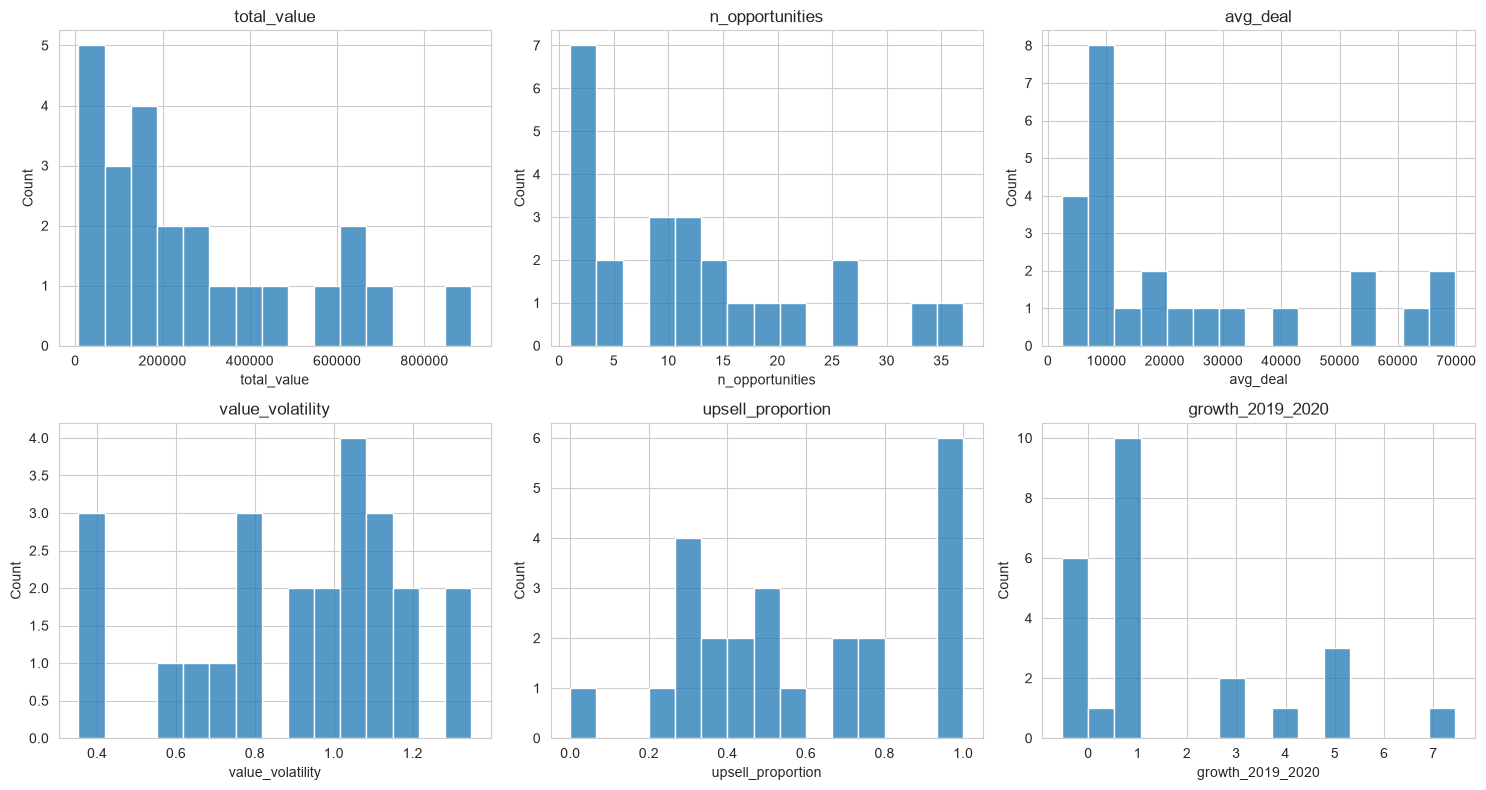

In [6]:
feature_cols_raw = ["total_value", "n_opportunities", "avg_deal", "value_volatility",
                    "upsell_proportion", "growth_2019_2020"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols_raw):
    sns.histplot(combo_base[col], bins=15, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [7]:
cluster_features = combo_base.copy()
cluster_features["log_total_value"] = np.log1p(cluster_features["total_value"])
cluster_features["log_avg_deal"] = np.log1p(cluster_features["avg_deal"])
cluster_features["log_n_opportunities"] = np.log1p(cluster_features["n_opportunities"])
# growth can be negative, so no log -- clip extreme values instead (small-n combos can show huge % swings)
cluster_features["growth_clipped"] = cluster_features["growth_2019_2020"].clip(-1, 3)

FEATURES = ["log_total_value", "log_n_opportunities", "log_avg_deal",
            "value_volatility", "upsell_proportion", "growth_clipped"]

X = cluster_features[FEATURES].copy()
X.describe()

,log_total_value,log_n_opportunities,log_avg_deal,value_volatility,upsell_proportion,growth_clipped
count,24.00,24.00,24.00,24.00,24.00,24.00
mean,12.02,2.24,9.62,0.91,0.59,1.15
std,1.20,0.89,1.00,0.28,0.30,1.32
min,8.89,0.69,7.79,0.35,0.00,-0.53
25%,11.42,1.39,9.00,0.75,0.36,0.00
50%,12.15,2.44,9.38,0.98,0.50,1.00
75%,12.89,2.86,10.45,1.10,0.82,3.00
max,13.72,3.64,11.15,1.35,1.00,3.00


## Scale features and reduce noise dimensionality (PCA for visualization only)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio (2 components): {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")
print(f"\nn combinations being clustered: {X_scaled.shape[0]}")

PCA explained variance ratio (2 components): [0.39618878 0.26411669]
Total variance explained: 66.0%

n combinations being clustered: 24


## Choosing the number of clusters

With a small number of combinations (check the count above -- likely well under 30), we test
k=2 through k=5 and pick based on silhouette score, favoring the simpler (lower k) option when
scores are close, since more clusters than the data can support just fits noise.

In [9]:
silhouette_results = []
for k in range(2, min(6, X_scaled.shape[0] - 1)):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df

,k,silhouette_score
0,2,0.37
1,3,0.30
2,4,0.32
3,5,0.33


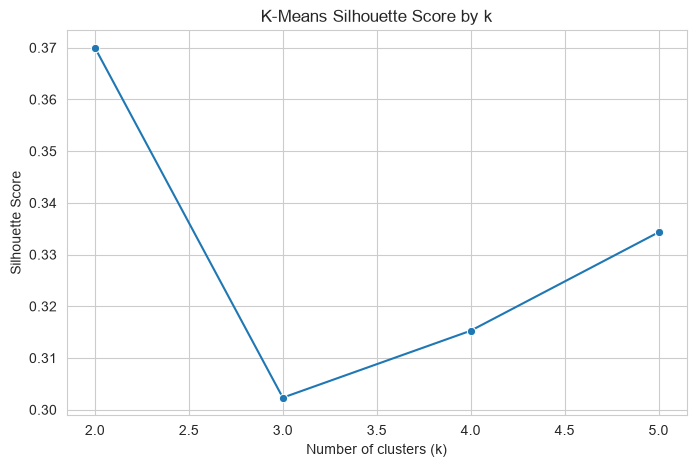

Best k by silhouette score: 2
Note: with this few combinations, treat 'best k' as a starting point, not gospel --
also sanity-check whether the resulting cluster PROFILES (below) actually tell a coherent business story.


In [10]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=silhouette_df, x="k", y="silhouette_score", marker="o")
plt.title("K-Means Silhouette Score by k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = int(silhouette_df.loc[silhouette_df["silhouette_score"].idxmax(), "k"])
print(f"Best k by silhouette score: {best_k}")
print("Note: with this few combinations, treat 'best k' as a starting point, not gospel --")
print("also sanity-check whether the resulting cluster PROFILES (below) actually tell a coherent business story.")

## Part 1 — K-Means

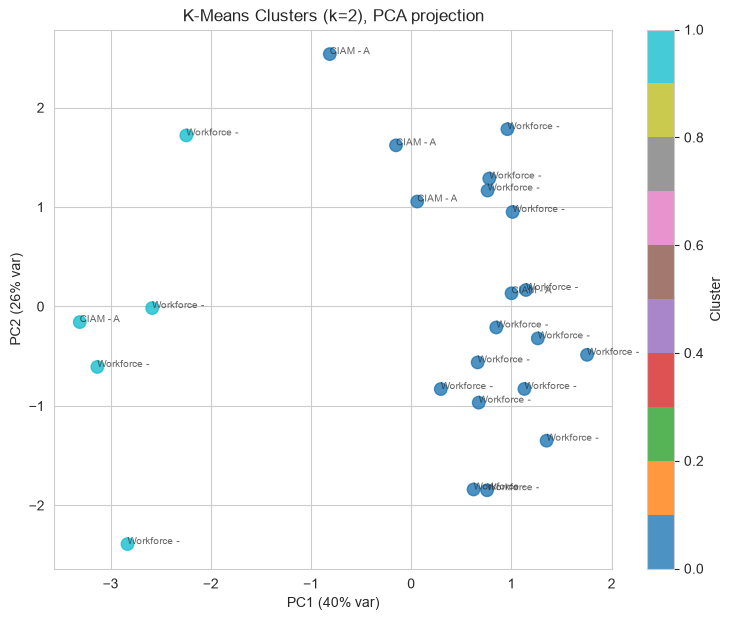

In [11]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_features["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_features["kmeans_cluster"], cmap="tab10", s=80, alpha=0.8)
for i, label in enumerate(cluster_features["combo_label"]):
    plt.annotate(label.split(" | ")[0][:12], (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
plt.title(f"K-Means Clusters (k={best_k}), PCA projection")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Part 2 — Gaussian Mixture Model

GMM silhouette score (k=2): 0.370
K-Means silhouette score (k=2): 0.370


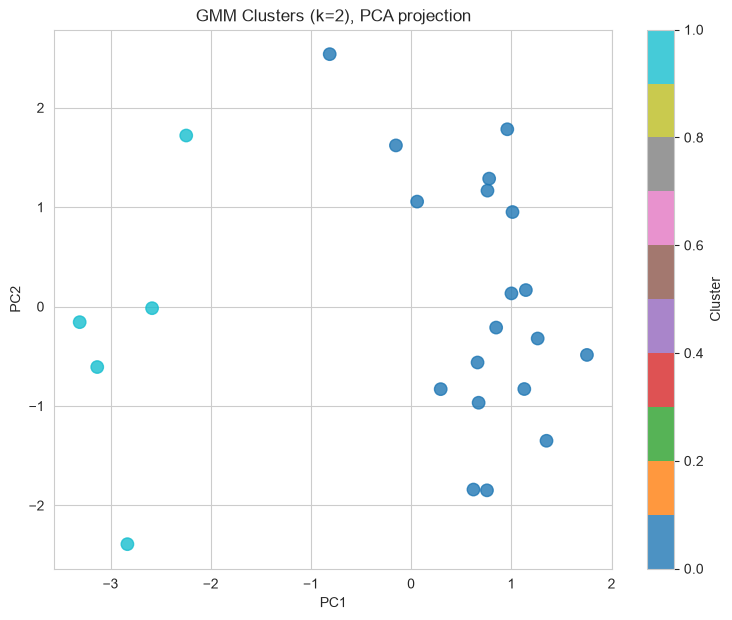

In [12]:
gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_features["gmm_cluster"] = gmm.fit_predict(X_scaled)

gmm_silhouette = silhouette_score(X_scaled, cluster_features["gmm_cluster"])
print(f"GMM silhouette score (k={best_k}): {gmm_silhouette:.3f}")
print(f"K-Means silhouette score (k={best_k}): {silhouette_df.loc[silhouette_df['k']==best_k, 'silhouette_score'].values[0]:.3f}")

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_features["gmm_cluster"], cmap="tab10", s=80, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM Clusters (k={best_k}), PCA projection")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Part 3 — Hierarchical clustering

Useful here specifically because it also shows the dendrogram, which with this few data points can be more informative than a forced k.

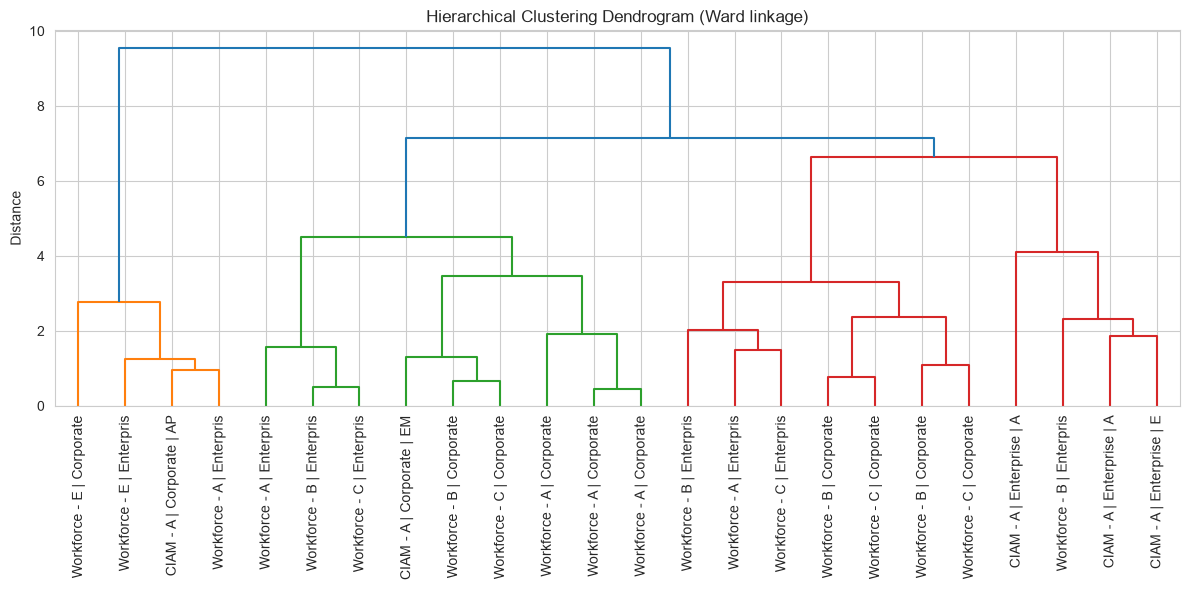

In [13]:
linkage_matrix = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=cluster_features["combo_label"].str.slice(0, 25).values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [14]:
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
cluster_features["hierarchical_cluster"] = hierarchical.fit_predict(X_scaled)

hier_silhouette = silhouette_score(X_scaled, cluster_features["hierarchical_cluster"])
print(f"Hierarchical clustering silhouette score (k={best_k}): {hier_silhouette:.3f}")

Hierarchical clustering silhouette score (k=2): 0.356


## Method comparison & stability check

How much do K-Means, GMM, and hierarchical clustering agree on which combinations belong together? High agreement = stable, trustworthy clusters. Low agreement = the structure is weak and cluster interpretations should be held loosely.

In [15]:
from sklearn.metrics import adjusted_rand_score

ari_km_gmm = adjusted_rand_score(cluster_features["kmeans_cluster"], cluster_features["gmm_cluster"])
ari_km_hier = adjusted_rand_score(cluster_features["kmeans_cluster"], cluster_features["hierarchical_cluster"])
ari_gmm_hier = adjusted_rand_score(cluster_features["gmm_cluster"], cluster_features["hierarchical_cluster"])

print("Adjusted Rand Index (1.0 = perfect agreement, 0.0 = random agreement):")
print(f"  K-Means vs GMM:          {ari_km_gmm:.3f}")
print(f"  K-Means vs Hierarchical: {ari_km_hier:.3f}")
print(f"  GMM vs Hierarchical:     {ari_gmm_hier:.3f}")

method_comparison = pd.DataFrame({
    "Method": ["K-Means", "GMM", "Hierarchical"],
    "Silhouette Score": [
        silhouette_df.loc[silhouette_df["k"] == best_k, "silhouette_score"].values[0],
        gmm_silhouette,
        hier_silhouette,
    ],
})
method_comparison

Adjusted Rand Index (1.0 = perfect agreement, 0.0 = random agreement):
  K-Means vs GMM:          1.000
  K-Means vs Hierarchical: 0.808
  GMM vs Hierarchical:     0.808


,Method,Silhouette Score
0,K-Means,0.37
1,GMM,0.37
2,Hierarchical,0.36


## Cluster profiles (using K-Means as the primary labeling, adjust if another method scored better/was more stable)

In [16]:
profile_cols = ["total_value", "n_opportunities", "avg_deal", "median_deal",
                "value_volatility", "upsell_proportion", "growth_2019_2020"]

cluster_profiles = (
    cluster_features
    .groupby("kmeans_cluster")[profile_cols]
    .mean()
    .round(2)
)
cluster_profiles["n_combinations"] = cluster_features.groupby("kmeans_cluster").size()
cluster_profiles

,total_value,n_opportunities,avg_deal,median_deal,value_volatility,upsell_proportion,growth_2019_2020,n_combinations
kmeans_cluster,,,,,,,,
0,"335,575.65",14.68,"24,910.67","19,145.39",1.02,0.48,1.87,19
1,"54,536.48",2.20,"18,788.93","20,822.83",0.48,1.00,0.72,5


In [17]:
cluster_features[["combo_label", "kmeans_cluster", "total_value", "n_opportunities",
                   "avg_deal", "growth_2019_2020", "upsell_proportion"]].sort_values(
    ["kmeans_cluster", "total_value"], ascending=[True, False]
)

,combo_label,kmeans_cluster,total_value,n_opportunities,avg_deal,growth_2019_2020,upsell_proportion
4,CIAM - A | Enterprise | EMEA,0,"907,271.46",3,"69,790.11",1.00,1.00
20,Workforce - C | Enterprise | AMER,0,"694,943.16",18,"33,092.53",-0.53,0.73
16,Workforce - B | Enterprise | EMEA,0,"629,937.47",10,"62,993.75",3.02,0.76
14,Workforce - B | Enterprise | AMER,0,"616,415.95",21,"29,353.14",-0.09,0.72
21,Workforce - C | Enterprise | EMEA,0,"580,393.51",13,"38,692.90",7.44,0.46
2,CIAM - A | Enterprise | AMER,0,"467,453.50",4,"51,939.28",1.00,0.50
8,Workforce - A | Enterprise | AMER,0,"376,483.73",25,"9,412.09",-0.47,0.76
13,Workforce - B | Corporate | EMEA,0,"316,595.25",33,"9,593.80",3.10,0.54
19,Workforce - C | Corporate | EMEA,0,"297,009.76",26,"9,281.56",4.06,0.50
10,Workforce - A | Enterprise | EMEA,0,"292,844.50",11,"17,226.15",5.22,0.37


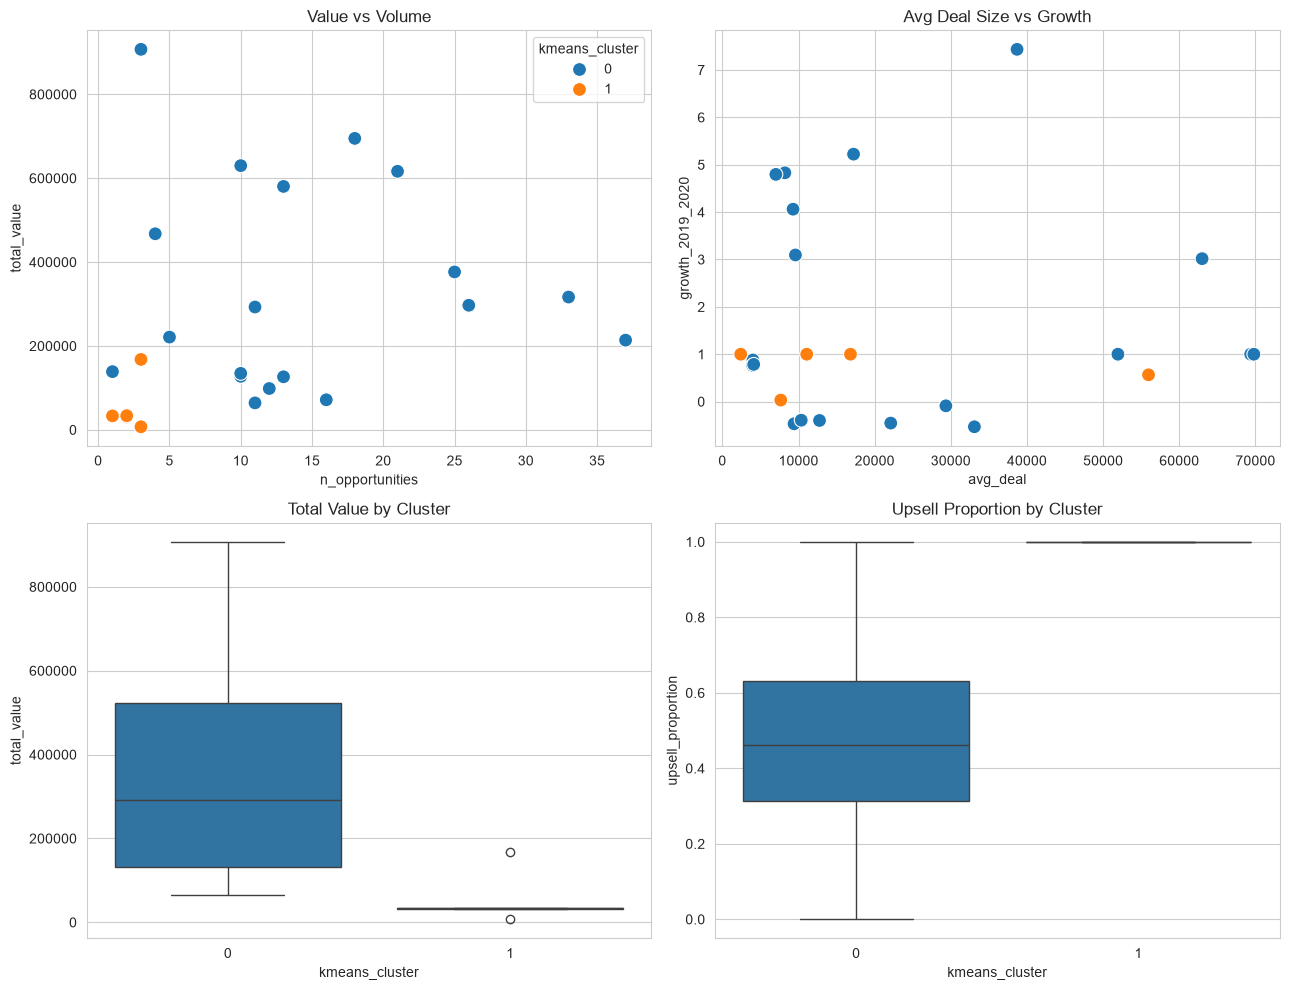

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.scatterplot(data=cluster_features, x="n_opportunities", y="total_value",
                 hue="kmeans_cluster", palette="tab10", s=100, ax=axes[0, 0])
axes[0, 0].set_title("Value vs Volume")

sns.scatterplot(data=cluster_features, x="avg_deal", y="growth_2019_2020",
                 hue="kmeans_cluster", palette="tab10", s=100, ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Avg Deal Size vs Growth")

sns.boxplot(data=cluster_features, x="kmeans_cluster", y="total_value", ax=axes[1, 0])
axes[1, 0].set_title("Total Value by Cluster")

sns.boxplot(data=cluster_features, x="kmeans_cluster", y="upsell_proportion", ax=axes[1, 1])
axes[1, 1].set_title("Upsell Proportion by Cluster")

plt.tight_layout()
plt.show()

### Naming the clusters

Look at `cluster_profiles` above and assign a business-meaningful name to each cluster number
based on ITS actual characteristics -- don't force-fit the archetypes below, only use the ones
that match what you see:

- **High-value mature markets**: high total_value, low/negative growth, low volatility
- **High-volume / lower-value markets**: high n_opportunities, low avg_deal
- **Emerging high-growth combinations**: high growth_2019_2020, lower total_value, possibly higher volatility
- **Low-volume / high-value strategic combinations**: low n_opportunities, high avg_deal
- **Highly concentrated / volatile markets**: high value_volatility, few opportunities

Fill in your actual cluster names here once you've inspected the output:

| Cluster | Name | Rationale |
|---|---|---|
| 0 | *(fill in)* | |
| 1 | *(fill in)* | |
| ... | | |

## Summary

24 combos qualified (≥2 line items). Silhouette peaked at k=2 (0.37) — a simple split, not a rich archetype set. All three methods agreed strongly (K-Means vs GMM: ARI=1.0 identical; vs Hierarchical: 0.81) — this is a genuinely stable 2-cluster structure, not noise.
Cluster 0 (19 combos): higher value ($335K avg), more opportunities (~15), higher volatility (1.02), mixed upsell (48%), high growth (1.87) — broad "core active" markets.
Cluster 1 (5 combos): much smaller ($55K avg), thin volume (~2 opportunities), lower volatility (0.48), 100% upsell, lower growth (0.72) — small, stable, upsell-only niches.
Net read across all three notebooks: Segment (Enterprise vs Corporate) is the dominant, statistically robust driver of value — everything else (geography, opportunity type, even product line on its own) is weaker or confounded by it. The combo-level concentration finding (HHI=0.07) is the most interesting/counterintuitive result and worth leading with in your write-up. Clustering only supports a 2-group split, not the richer "4 archetypes" the project doc imagined — that's a legitimate, honest finding given n=24 combos, not a shortcoming of the notebook.
Ready for 06_opportunity_scoring.ipynb whenever you want it — it can lean directly on these outputs (HHI/Gini for risk, regression coefficients for value drivers, cluster assignment for archetype).